# 05 - Evaluation (Phase 5)

## Setup

Same connection pattern as `01_eda.ipynb` through `04_supervised.ipynb` -
credentials from `.env`, jupysql for SQL cells, pandas/sklearn pulled in
only where a chart, a metric, or a model needs them.

This is the synthesis notebook. Every detection method built in Phase 4a
(`02_methods.ipynb`, `03_reconciliation.ipynb`) and Phase 4b
(`04_supervised.ipynb`) is re-run here against **the same test set** and
scored against `ground_truth`, so the numbers are comparable for the first
time. Like `04_supervised.ipynb` - and unlike 01/02/03 - this notebook
queries `ground_truth`. Same Hard rule applies: labels only, joined at
evaluation time by `header_id` / `line_id` / `bank_txn_id`, never written
back into `journal_entry_features`.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

%load_ext sql

In [2]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

user = quote_plus(os.environ["PGUSER"])
password = quote_plus(os.environ["PGPASSWORD"])
conn_str = (
    f"postgresql+psycopg2://{user}:{password}"
    f"@{os.environ['PGHOST']}:{os.environ['PGPORT']}/{os.environ['PGDATABASE']}"
)
engine = create_engine(conn_str)

%sql engine
%config SqlMagic.displaylimit = 20
%config SqlMagic.feedback = False
%config SqlMagic.autopandas = False

## 1. The evaluation frame

Three decisions fix what every number below means.

**The test set.** Phase 2 cut a chronological split into
`journal_entry_features.split` - the first 18 fiscal periods are `train`,
the last 6 (`2025-07` to `2025-12`) are `test`. Phase 4b trained on
`train` and reported on `test`. The unsupervised methods never had a
training set at all, but they get scored on the *same* `test` rows anyway:
a method evaluated on a different population isn't comparable, and the
whole point of this notebook is comparability. Bank-side reconciliation
metrics use the matching window (`value_date` inside the test period),
since a bank row has no `split` of its own.

**Two scoreboards, never blended.** Per the Phase plan:

- **Unsupervised (Scoreboard A)** - Benford, segmented z-score, segmented
  IQR, Isolation Forest, reconciliation. No labels were used to build,
  tune, or threshold any of these. This is the **realistic** estimate of
  what the methods would do on data whose errors nobody has labelled -
  i.e. real data.
- **Supervised (Scoreboard B)** - logistic regression, random forest,
  XGBoost, trained on labelled train-period rows. Labels existed during
  training, so this is the **optimistic** bound: it assumes an
  organisation already has a labelled history of its own errors, which is
  exactly the thing most finance teams do not have.

Ranking a blind detector against a label-trained model on one leaderboard
would hide that difference, so the two are reported separately throughout
and only brought together in Section 4 (which method wins *per error
type*) and Section 5 (the layered system).

**Two accounting levels.** Header-level metrics (precision / recall / F1 /
AP) treat one journal header as one prediction against the binary
`is_error`. Per-error-type recall is computed at the **(header,
error_type) pair** level, because 18 headers carry two `ground_truth` rows
each and should count toward both types' recall. Both levels appear below
and are labelled wherever they could be confused.

In [3]:
%%sql labelled_rs <<
-- Feature table + labels, joined by header_id at evaluation time only.
-- The array_agg sub-select rolls ground_truth's one-row-per-finding shape
-- up to one row per header, so the LEFT JOIN stays 1:1 against the feature
-- table; the arrays absorb the ~18 headers carrying two findings.
-- WHERE header_id IS NOT NULL drops the phantom bank-side unmatched_bank
-- rows, which have no ledger header to attach to - they are scored
-- separately, on the bank side, in Section 2.4.
SELECT
    f.*,
    (g.header_id IS NOT NULL)                      AS is_error,
    COALESCE(g.error_types, ARRAY[]::text[])       AS error_types,
    COALESCE(g.detectabilities, ARRAY[]::text[])   AS detectabilities
FROM journal_entry_features f
LEFT JOIN (
    SELECT
        header_id,
        array_agg(DISTINCT error_type)    AS error_types,
        array_agg(DISTINCT detectability) AS detectabilities
    FROM ground_truth
    WHERE header_id IS NOT NULL
    GROUP BY header_id
) g ON g.header_id = f.header_id;

In [4]:
import numpy as np
import pandas as pd

df = labelled_rs.DataFrame().set_index("header_id", drop=False)
test_df = df[df["split"] == "test"].copy()
y_test_binary = test_df["is_error"].astype(int)

print(f"full feature table : {len(df):,} headers")
print(f"test period        : {len(test_df):,} headers "
      f"({test_df['fiscal_period'].min()} .. {test_df['fiscal_period'].max()})")
print(f"positives in test  : {int(y_test_binary.sum()):,} "
      f"({y_test_binary.mean():.2%} of test headers)")

full feature table : 113,981 headers
test period        : 28,695 headers (2025-07 .. 2025-12)
positives in test  : 1,293 (4.51% of test headers)


In [5]:
# One row per (header, error_type) pair for the test-period positives.
# A doubly-labelled header appears twice, so it counts toward the recall of
# both error types it actually carries - the pair-level accounting the
# markdown above describes.
def explode_labels(frame):
    rows = []
    for _, r in frame[frame["is_error"]].iterrows():
        for error_type, detectability in zip(r["error_types"], r["detectabilities"]):
            rows.append({
                "header_id": r["header_id"],
                "error_type": error_type,
                "detectability": detectability,
            })
    return pd.DataFrame(rows).set_index("header_id", drop=False)

pairs = explode_labels(test_df)
print(f"{len(pairs)} labelled (header, error_type) pairs in the test period\n")
# .to_numpy() on both sides: pairs' index repeats a header_id for the
# doubly-labelled headers, and crosstab aligns on the index.
print(pd.crosstab(pd.Series(pairs["error_type"].to_numpy(), name="error_type"),
                  pd.Series(pairs["detectability"].to_numpy(), name="detectability"))
        .reindex(columns=["easy", "medium", "hard"], fill_value=0))

1297 labelled (header, error_type) pairs in the test period

detectability         easy  medium  hard
error_type                              
backdated               11      40   130
duplicate               24     114     0
off_hours_posting        1     153     0
round_number           274       0     0
structuring              2       0   240
unbalanced              76       0     0
unmatched_bank          32      23    27
unusual_account_pair     0       0   150


In [6]:
%%sql gt_bank_rs <<
-- unmatched_bank is the one error_type labelled on both sides of the
-- orphan pair (see sql/01_schema.sql): ledger-side rows carry
-- header_id/line_id with bank_txn_id NULL, bank-side phantom rows carry
-- bank_txn_id with both ledger keys NULL. Section 2.4 scores each side
-- against the side it can actually see.
SELECT header_id, line_id, bank_txn_id, detectability
FROM ground_truth
WHERE error_type = 'unmatched_bank';

In [7]:
gt_bank = gt_bank_rs.DataFrame()
gt_ledger_lines = set(gt_bank.loc[gt_bank["line_id"].notna(), "line_id"].astype("int64"))
gt_phantom_bank = set(gt_bank.loc[gt_bank["bank_txn_id"].notna(), "bank_txn_id"].astype("int64"))
print(f"unmatched_bank - ledger-side labels: {len(gt_ledger_lines):,} lines")
print(f"unmatched_bank - bank-side labels  : {len(gt_phantom_bank):,} bank rows")

unmatched_bank - ledger-side labels: 318 lines
unmatched_bank - bank-side labels  : 318 bank rows


In [8]:
# Shared metric helpers, used by both scoreboards so the two are computed
# by identical code rather than two similar-looking blocks.
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, precision_recall_curve,
)

def binary_metrics(y_true, y_pred, name, n_flagged_note=None):
    return {
        "method": name,
        "flagged": int(np.asarray(y_pred).sum()),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

def recall_by(frame, flag_cols, by):
    """Pair-level recall: share of labelled (header, error_type) pairs whose
    header was flagged, grouped by error_type or detectability."""
    out = frame.groupby(by)[flag_cols].mean().round(3)
    out["n"] = frame.groupby(by).size()
    return out

PALETTE = {
    "Benford (account MAD)":  "#2a78d6",
    "Segmented z-score":      "#eb6834",
    "Segmented IQR":          "#1baf7a",
    "Isolation Forest":       "#a259d9",
    "Reconciliation":         "#d64550",
    "Logistic Regression":    "#2a78d6",
    "Random Forest":          "#eb6834",
    "XGBoost":                "#1baf7a",
}

## 2. Scoreboard A - unsupervised (the realistic estimate)

Five blind methods, re-run exactly as `02_methods.ipynb` and
`03_reconciliation.ipynb` built them, then scored on test-period rows.
Nothing here saw a label at any point: the accounts Benford flags, the
z/IQR fences, Isolation Forest's `contamination`, and the reconciliation
thresholds were all chosen from the data's own shape.

Two of them don't cover the whole test set, and pretending otherwise
would flatter them:

- **z-score / IQR / Isolation Forest** are restricted to
  `account_entry_seq > 10` (Phase 2 leaves `account_amount_zscore` NULL
  below 11 prior entries for that account - a mean and stddev from a
  handful of points is noise, not a baseline).
- **Reconciliation** only sees journal headers with a cash line. It has
  no opinion at all about a payroll accrual.

Uncovered rows are scored as **not flagged**, not dropped. A method that
structurally cannot see part of the population genuinely does not catch
the errors hiding there, and the coverage column below says exactly how
much of the test set each one could see.

### 2.1 Benford - MAD-ranked, not p-value-ranked

`02_methods.ipynb` found the p-value useless as a *ranking* device at this
sample size: with 113,981 entries the aggregate chi-square rejects
(p < 0.0001) on a mean absolute deviation of 0.50 percentage points, which
is practically conformant. Chi-square scales with `n`, so ranking accounts
by p-value mostly ranks them by how many entries they have. MAD (the mean
absolute deviation between observed and expected digit proportions, in
percentage points) is an effect size - it doesn't grow with `n` - so it is
the ranking used here, per the standard Nigrini conformity bands.

Benford is an **account-level** test; it is not defined for a single
number. The entry-level score is therefore its primary account's MAD, and
the flag is "this entry's primary account sits in the worst decile of
tested accounts by MAD" - an account-level suspicion pushed down to its
entries, which is how the test is used in practice (pick the account, then
go read its entries).

In [9]:
%%sql primary_account_rs <<
-- One primary account per header: the account on the largest line, ties
-- broken by line_num. DISTINCT ON is Postgres' cheap "first row per group"
-- - the ORDER BY inside it is what defines "first", not a sort for display.
SELECT DISTINCT ON (l.header_id)
    l.header_id,
    l.account_key AS primary_account_key,
    a.account_id,
    a.account_name
FROM journal_line l
JOIN dim_account a ON a.account_key = l.account_key
ORDER BY l.header_id, (l.debit_amount + l.credit_amount) DESC, l.line_num ASC;

In [10]:
from scipy.stats import chisquare

primary_account_df = primary_account_rs.DataFrame().set_index("header_id")

digits = np.arange(1, 10)
benford_probs = np.log10(1 + 1 / digits)

# Digit counts per account over the WHOLE ledger, not just test rows: the
# Benford baseline for an account is a property of that account's history,
# and restricting it to six months would just make the test noisier. The
# scoring below is still test-rows-only.
digit_frame = df[["leading_digit"]].join(primary_account_df, how="inner").dropna(subset=["leading_digit"])
pivot = (
    digit_frame.pivot_table(index="primary_account_key", columns="leading_digit",
                            aggfunc="size", fill_value=0)
    .reindex(columns=range(1, 10), fill_value=0)
)

MIN_N = 50
rows = []
for acct_key, row in pivot.iterrows():
    n = row.sum()
    if n < MIN_N:
        continue
    stat, p = chisquare(f_obs=row.values, f_exp=benford_probs * n)
    rows.append({
        "primary_account_key": acct_key,
        "n": int(n),
        "chi2": stat,
        "p_value": p,
        "mad_pct_points": np.mean(np.abs(row.values / n - benford_probs)) * 100,
    })

benford_acct = pd.DataFrame(rows).set_index("primary_account_key").sort_values(
    "mad_pct_points", ascending=False)

MAD_DECILE = benford_acct["mad_pct_points"].quantile(0.90)
benford_acct["worst_decile"] = benford_acct["mad_pct_points"] >= MAD_DECILE
print(f"{len(benford_acct)} accounts tested at n >= {MIN_N}; "
      f"worst-decile MAD cutoff = {MAD_DECILE:.3f} pp; "
      f"{int(benford_acct['worst_decile'].sum())} accounts flagged")
benford_acct.head(8).round(3)

27 accounts tested at n >= 50; worst-decile MAD cutoff = 2.070 pp; 3 accounts flagged


,n,chi2,p_value,mad_pct_points,worst_decile
primary_account_key,,,,,
19,7482,3375.947,0.000,5.838,True
10,309,12.740,0.121,2.108,True
13,294,17.636,0.024,2.082,True
5,296,15.143,0.056,2.061,False
2,311,13.533,0.095,1.920,False
9,231,17.477,0.026,1.835,False
14,297,8.507,0.386,1.797,False
6,261,14.198,0.077,1.696,False


In [11]:
# Push the account-level result down to test-period entries.
test_primary = test_df[["header_id"]].join(primary_account_df["primary_account_key"], how="left")
benford_score = test_primary["primary_account_key"].map(benford_acct["mad_pct_points"])
benford_flag = test_primary["primary_account_key"].map(
    benford_acct["worst_decile"]).fillna(False).astype(bool)

print(f"test entries with a testable primary account: "
      f"{benford_score.notna().sum():,} / {len(test_df):,}")
print(f"flagged by Benford (worst-decile account): {int(benford_flag.sum()):,}")

test entries with a testable primary account: 28,695 / 28,695
flagged by Benford (worst-decile account): 2,064


### 2.2 Segmented z-score and IQR

Both computed **within account**, as in `02_methods.ipynb` - a $50k entry
is routine for Cash Operating and an outlier for a small expense account.
The z-score reuses `account_amount_zscore` straight from the Phase 2
feature table (an expanding window ordered by `posting_datetime`, so a
test-period entry's z-score is computed against that account's *prior*
history only, never against the future); the IQR fences are computed in
SQL with `PERCENTILE_CONT`.

Scores for the PR curves: `|z|` for the z-score rule, and for IQR the
distance past the nearer fence expressed in IQRs (0 inside the fence),
which is the continuous quantity the 1.5x rule thresholds.

In [12]:
%%sql seg_outlier_rs <<
WITH primary_account AS (
    SELECT DISTINCT ON (header_id) header_id, account_key AS primary_account_key
    FROM journal_line
    ORDER BY header_id, (debit_amount + credit_amount) DESC, line_num ASC
),
eligible AS (
    -- account_entry_seq > 10: same scored population as 02_methods.ipynb.
    SELECT f.header_id, pa.primary_account_key, f.total_amount,
           f.account_amount_zscore, f.split
    FROM journal_entry_features f
    JOIN primary_account pa ON pa.header_id = f.header_id
    WHERE f.account_entry_seq > 10
),
acct_stats AS (
    -- Quartiles per account over the account's whole history, same
    -- reasoning as Benford's baseline above.
    SELECT primary_account_key,
           PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY total_amount) AS q1,
           PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY total_amount) AS q3
    FROM eligible
    GROUP BY primary_account_key
)
SELECT e.header_id, e.split, e.total_amount, e.account_amount_zscore,
       s.q1, s.q3
FROM eligible e
JOIN acct_stats s ON s.primary_account_key = e.primary_account_key;

In [13]:
outlier_df = seg_outlier_rs.DataFrame().set_index("header_id")
for c in ["total_amount", "account_amount_zscore", "q1", "q3"]:
    outlier_df[c] = outlier_df[c].astype(float)

iqr = (outlier_df["q3"] - outlier_df["q1"]).replace(0, np.nan)
lower, upper = outlier_df["q1"] - 1.5 * iqr, outlier_df["q3"] + 1.5 * iqr
# distance past the nearer fence, in IQRs - 0 for anything inside
outlier_df["iqr_distance"] = np.maximum(
    (lower - outlier_df["total_amount"]) / iqr,
    (outlier_df["total_amount"] - upper) / iqr,
).clip(lower=0).fillna(0)
outlier_df["abs_z"] = outlier_df["account_amount_zscore"].abs()

z_score_all = outlier_df["abs_z"]
iqr_score_all = outlier_df["iqr_distance"]

zscore_score = z_score_all.reindex(test_df.index)
iqr_score = iqr_score_all.reindex(test_df.index)
zscore_flag = (zscore_score > 3).fillna(False)
iqr_flag = (iqr_score > 1.5).fillna(False)   # >1.5 IQR past the fence == the classic 1.5x rule

print(f"scored population in test: {zscore_score.notna().sum():,} / {len(test_df):,}")
print(f"z-score flags: {int(zscore_flag.sum()):,}   IQR flags: {int(iqr_flag.sum()):,}   "
      f"either: {int((zscore_flag | iqr_flag).sum()):,}")

scored population in test: 28,695 / 28,695
z-score flags: 308   IQR flags: 1,539   either: 1,540


### 2.3 Isolation Forest

Multivariate, over the same numeric feature matrix `02_methods.ipynb`
used and the same scored population (`account_entry_seq > 10`), with
`contamination=0.03` - which is *not* a label-derived number: 3% is
CLAUDE.md's stated seeding target, known to whoever generated the data,
and in a real deployment it would be a review-capacity budget ("we can
look at 3% of entries"), not a measured error rate. The anomaly score is
the continuous output; the flag is the model's own `predict == -1`.

One honest caveat, stated before the numbers: the forest is fitted on the
whole ledger, including test rows. That's standard for an unsupervised
detector - it's a description of the data's own density, and no labels
enter - but it is not a held-out fit in the way Scoreboard B's models are.

In [14]:
%%sql if_features_rs <<
SELECT
    header_id,
    log_amount, entry_line_count, description_length, post_lag_days,
    days_from_period_end, account_entry_seq, employee_entry_seq,
    user_account_frequency, user_entry_count_month, account_pair_frequency,
    pct_of_account_monthly_total, account_amount_zscore,
    is_round_100::int       AS is_round_100,
    is_round_1000::int      AS is_round_1000,
    is_round_10000::int     AS is_round_10000,
    is_period_end::int      AS is_period_end,
    is_after_hours::int     AS is_after_hours,
    is_weekend::int         AS is_weekend,
    is_manual_entry::int    AS is_manual_entry,
    is_first_time_pair::int AS is_first_time_pair,
    has_description::int    AS has_description
FROM journal_entry_features
WHERE account_entry_seq > 10;

In [15]:
from sklearn.ensemble import IsolationForest

if_df = if_features_rs.DataFrame().set_index("header_id")
iso_forest = IsolationForest(n_estimators=200, contamination=0.03,
                             random_state=42, n_jobs=-1)
iso_forest.fit(if_df.values)

if_scores = pd.Series(-iso_forest.decision_function(if_df.values), index=if_df.index)
if_flags = pd.Series(iso_forest.predict(if_df.values) == -1, index=if_df.index)

iforest_score = if_scores.reindex(test_df.index)
iforest_flag = if_flags.reindex(test_df.index).fillna(False).astype(bool)
print(f"Isolation Forest flags in test: {int(iforest_flag.sum()):,} "
      f"of {int(iforest_score.notna().sum()):,} scored")

Isolation Forest flags in test: 1,814 of 28,695 scored


### 2.4 Reconciliation

`03_reconciliation.ipynb` left one question open on purpose: whether the
two-stage match (JE-number recovery, then `rapidfuzz` on the reference
text) is actually *right*. Here it gets scored - and, more usefully, two
different ways of turning reconciliation into a detector get compared:

1. **"unmatched after text scoring"** - a ledger cash line is suspicious
   if no bank row ended up matched to it once Stage 1 and Stage 2 have
   run. This is the natural reading of a reconciliation report.
2. **"no blocking candidate at all"** - a ledger cash line is suspicious
   only if no bank row exists anywhere within one cent and the 0-3 day
   clearing window. This ignores the reference text entirely and asks a
   strictly structural question.

Both are blind. The bank side is scored the same way, symmetrically, for
phantom rows. Section 9 of `03_reconciliation.ipynb` predicted, without
labels, that the text threshold was the weak link - this is where that
prediction gets tested.

In [16]:
%%sql recon_candidate_rs <<
WITH ledger_cash AS (
    -- Every journal_line hitting a cash account, with the signed amount a
    -- bank feed would show and the label word the reference started from.
    -- The label is a business rule over account_id + debit/credit, not a
    -- ground_truth field - reconstructing it is not leakage.
    SELECT h.header_id, h.header_id_text, l.line_id,
           (l.debit_amount - l.credit_amount) AS signed_amount,
           h.posting_datetime::date AS ledger_date,
           CASE WHEN l.debit_amount > 0    THEN 'CUSTOMER RECEIPT'
                WHEN a.account_id = '1010' THEN 'PAYROLL TRANSFER'
                ELSE 'VENDOR PAYMENT' END  AS label
    FROM journal_line l
    JOIN journal_header h ON h.header_id = l.header_id
    JOIN dim_account a    ON a.account_key = l.account_key
    WHERE a.is_cash_account
)
-- Blocking join: amount equal to the cent, value_date inside the 0-3 day
-- clearing window. INNER JOIN on purpose - rows with no candidate on
-- either side are found by set difference below, which is far cheaper than
-- an anti-join over this range condition.
SELECT b.bank_txn_id, b.value_date, b.amount, b.reference,
       lg.header_id, lg.header_id_text, lg.line_id, lg.ledger_date, lg.label,
       ABS(b.amount - lg.signed_amount) AS amount_diff,
       (b.value_date - lg.ledger_date)  AS lag_days
FROM bank_transactions b
JOIN ledger_cash lg
  ON ABS(b.amount - lg.signed_amount) < 0.01
 AND b.value_date BETWEEN lg.ledger_date AND lg.ledger_date + 3;

In [17]:
%%sql ledger_cash_rs <<
-- Every ledger cash line with the split of its header, so the ledger side
-- of reconciliation can be scored on exactly the test-period population
-- the rest of this notebook uses.
SELECT h.header_id, l.line_id, f.split
FROM journal_line l
JOIN journal_header h            ON h.header_id = l.header_id
JOIN dim_account a               ON a.account_key = l.account_key
JOIN journal_entry_features f    ON f.header_id = h.header_id
WHERE a.is_cash_account;

In [18]:
%%sql all_bank_rs <<
SELECT bank_txn_id, value_date FROM bank_transactions;

In [19]:
import re
from rapidfuzz import fuzz

cand = recon_candidate_rs.DataFrame()
cand["amount_diff"] = cand["amount_diff"].astype(float)
cand["lag_days"] = cand["lag_days"].astype(int)

# --- Stage 1: recover a JE number from the bank reference ---------------
je_pattern = re.compile(r"JE-\d+", re.IGNORECASE)
def extract_je(reference):
    m = je_pattern.search(reference or "")
    return m.group(0).upper() if m else None

cand["extracted_je"] = cand["reference"].apply(extract_je)
cand["je_match"] = cand["extracted_je"] == cand["header_id_text"]
stage1 = cand[cand["je_match"]].sort_values("bank_txn_id").drop_duplicates("bank_txn_id")

matched_lines = set(stage1["line_id"])
matched_bank = set(stage1["bank_txn_id"])

# --- Stage 2: composite score on the remainder --------------------------
# Weights from 03_reconciliation.ipynb Section 10's recommended default
# (0.3 amount / 0.3 date / 0.4 string at threshold 0.50) - chosen there on
# blind grounds, carried over unchanged rather than re-tuned against labels.
rem = cand[~cand["bank_txn_id"].isin(matched_bank)].copy()
rem["candidate_ref"] = rem["label"] + " " + rem["header_id_text"]
rem["string_score"] = [fuzz.partial_ratio(a, b) / 100
                       for a, b in zip(rem["reference"], rem["candidate_ref"])]
rem["amount_score"] = 1 - (rem["amount_diff"] / 0.01).clip(upper=1)
rem["date_score"] = 1 - (rem["lag_days"] / 3).clip(lower=0, upper=1)
rem["composite"] = 0.3 * rem["amount_score"] + 0.3 * rem["date_score"] + 0.4 * rem["string_score"]

best = rem.sort_values("composite", ascending=False).groupby("bank_txn_id", as_index=False).nth(0)
accepted = best[best["composite"] >= 0.50]
matched_lines |= set(accepted["line_id"])
matched_bank |= set(accepted["bank_txn_id"])

print(f"Stage 1 (JE number) matched : {len(stage1):,} bank rows")
print(f"Stage 2 (composite >= 0.50) : {len(accepted):,} more")
print(f"total matched               : {len(matched_bank):,} of "
      f"{cand['bank_txn_id'].nunique():,} blocked bank rows")

Stage 1 (JE number) matched : 28,546 bank rows
Stage 2 (composite >= 0.50) : 18,914 more
total matched               : 47,460 of 52,672 blocked bank rows


In [20]:
ledger_cash = ledger_cash_rs.DataFrame()
test_cash = ledger_cash[ledger_cash["split"] == "test"].copy()

blocked_lines = set(cand["line_id"])
test_cash["unmatched_after_text"] = ~test_cash["line_id"].isin(matched_lines)
test_cash["no_blocking_candidate"] = ~test_cash["line_id"].isin(blocked_lines)
test_cash["is_orphan"] = test_cash["line_id"].isin(gt_ledger_lines)

recon_variants = pd.DataFrame([
    binary_metrics(test_cash["is_orphan"], test_cash[c], label)
    for c, label in [("unmatched_after_text", "ledger side: unmatched after text scoring"),
                     ("no_blocking_candidate", "ledger side: no blocking candidate")]
]).set_index("method").round(3)
recon_variants["labelled_orphans"] = int(test_cash["is_orphan"].sum())
recon_variants["population"] = len(test_cash)
recon_variants

,flagged,precision,recall,f1,labelled_orphans,population
method,,,,,,
ledger side: unmatched after text scoring,1389,0.06,1.000,0.114,84,13372
ledger side: no blocking candidate,83,1.00,0.988,0.994,84,13372


In [21]:
# Bank side, same two questions - but "no blocking candidate" is the only
# one that makes sense here: a phantom row has no ledger counterpart by
# construction, so there is nothing for text scoring to be right about.
all_bank = all_bank_rs.DataFrame()
all_bank["value_date"] = pd.to_datetime(all_bank["value_date"])
test_lo, test_hi = test_df["fiscal_period"].min(), test_df["fiscal_period"].max()
bank_test = all_bank[all_bank["value_date"].dt.strftime("%Y-%m").between(test_lo, test_hi)].copy()

blocked_bank = set(cand["bank_txn_id"])
bank_test["no_blocking_candidate"] = ~bank_test["bank_txn_id"].isin(blocked_bank)
bank_test["is_phantom"] = bank_test["bank_txn_id"].isin(gt_phantom_bank)

bank_side = pd.DataFrame([
    binary_metrics(bank_test["is_phantom"], bank_test["no_blocking_candidate"],
                   "bank side: no blocking candidate")
]).set_index("method").round(3)
bank_side["labelled_phantoms"] = int(bank_test["is_phantom"].sum())
bank_side["population"] = len(bank_test)
bank_side

,flagged,precision,recall,f1,labelled_phantoms,population
method,,,,,,
bank side: no blocking candidate,76,1.0,0.987,0.993,77,13224


**Finding - the text stage is the whole problem, and the blocking stage is
almost perfect.** (Numbers in the two tables above.) Asking "did anything
match this line after text scoring?" finds every seeded ledger orphan but
drowns them in false positives - nearly all of which are real ledger lines
whose bank row exists and is sitting right there in the block, rejected
only because `candidate_ref` has no counterparty text to match on. Asking
the structural question instead - "does a bank row within one cent and
three days exist at all?" - is near-perfect in both directions.

This is `03_reconciliation.ipynb` Section 9's blind diagnosis confirmed
against labels: the loss was a scoring problem, not a blocking problem.
It also settles which variant belongs in a production stack - the
structural one - and Section 5 uses it as the `unmatched_bank` layer.

In [22]:
# Reconciliation as a header-level detector, for Scoreboard A: a test
# header is flagged if any of its cash lines has no blocking candidate.
recon_flag_headers = set(
    test_cash.loc[test_cash["no_blocking_candidate"], "header_id"].astype("int64"))
recon_flag = pd.Series(test_df["header_id"].isin(recon_flag_headers).values,
                       index=test_df.index)
recon_covered = test_df["header_id"].isin(set(test_cash["header_id"].astype("int64"))).values

print(f"headers with a cash line (reconciliation's coverage): "
      f"{recon_covered.sum():,} of {len(test_df):,}")
print(f"headers flagged by reconciliation: {int(recon_flag.sum()):,}")

headers with a cash line (reconciliation's coverage): 12,055 of 28,695
headers flagged by reconciliation: 83


### 2.5 Scoreboard A

All five methods against the binary `is_error`, on the same 28,695 test
headers. `coverage` is the share of test headers the method could see at
all; a method is credited with no catches outside its coverage.

In [23]:
unsup_flags = pd.DataFrame({
    "Benford (account MAD)": benford_flag.values,
    "Segmented z-score":     zscore_flag.values,
    "Segmented IQR":         iqr_flag.values,
    "Isolation Forest":      iforest_flag.values,
    "Reconciliation":        recon_flag.values,
}, index=test_df.index)

unsup_coverage = {
    "Benford (account MAD)": benford_score.notna().mean(),
    "Segmented z-score":     zscore_score.notna().mean(),
    "Segmented IQR":         iqr_score.notna().mean(),
    "Isolation Forest":      iforest_score.notna().mean(),
    "Reconciliation":        recon_covered.mean(),
}

# Continuous scores for the PR curves. Uncovered rows get a score below the
# method's own minimum rather than being dropped - the curve then describes
# the whole test set, which is what makes it comparable to Scoreboard B's.
def fill_uncovered(s):
    return s.fillna(s.min() - 1) if s.notna().any() else s.fillna(0)

unsup_scores = pd.DataFrame({
    "Benford (account MAD)": fill_uncovered(benford_score).values,
    "Segmented z-score":     fill_uncovered(zscore_score).values,
    "Segmented IQR":         fill_uncovered(iqr_score).values,
    "Isolation Forest":      fill_uncovered(iforest_score).values,
}, index=test_df.index)

scoreboard_a = pd.DataFrame([
    binary_metrics(y_test_binary, unsup_flags[m], m) for m in unsup_flags.columns
]).set_index("method")
scoreboard_a["coverage"] = pd.Series(unsup_coverage)
scoreboard_a["average_precision"] = pd.Series({
    m: average_precision_score(y_test_binary, unsup_scores[m]) for m in unsup_scores.columns
})
scoreboard_a.round(3)

,flagged,precision,recall,f1,coverage,average_precision
method,,,,,,
Benford (account MAD),2064,0.058,0.092,0.071,1.00,0.049
Segmented z-score,308,0.464,0.111,0.179,1.00,0.181
Segmented IQR,1539,0.248,0.295,0.269,1.00,0.163
Isolation Forest,1814,0.175,0.245,0.204,1.00,0.214
Reconciliation,83,1.000,0.064,0.121,0.42,NaN


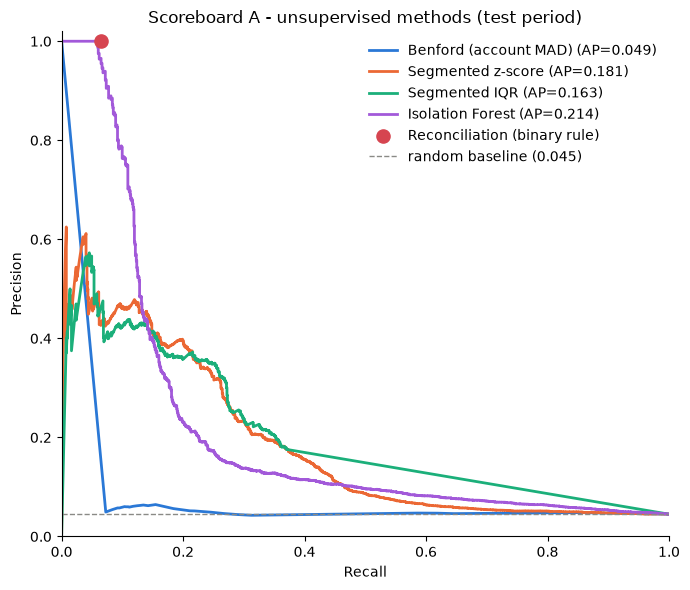

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
for m in unsup_scores.columns:
    prec, rec, _ = precision_recall_curve(y_test_binary, unsup_scores[m])
    ap = average_precision_score(y_test_binary, unsup_scores[m])
    ax.plot(rec, prec, lw=2, color=PALETTE[m], label=f"{m} (AP={ap:.3f})")

# Reconciliation is a structural yes/no with no score behind it, so it is a
# point on this plane, not a curve.
ax.scatter(scoreboard_a.loc["Reconciliation", "recall"],
           scoreboard_a.loc["Reconciliation", "precision"],
           s=90, color=PALETTE["Reconciliation"], zorder=5,
           label="Reconciliation (binary rule)")

base = y_test_binary.mean()
ax.axhline(base, color="#8a8a86", lw=1, ls="--", label=f"random baseline ({base:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Scoreboard A - unsupervised methods (test period)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.legend(loc="upper right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [25]:
unsup_pairs = pairs.join(unsup_flags, how="left")
unsup_recall_type = recall_by(unsup_pairs, list(unsup_flags.columns), "error_type")
unsup_recall_type.sort_values("n", ascending=False)

,Benford (account MAD),Segmented z-score,Segmented IQR,Isolation Forest,Reconciliation,n
error_type,,,,,,
round_number,0.077,0.354,0.599,0.781,0.004,274
structuring,0.140,0.174,0.777,0.190,0.008,242
backdated,0.066,0.011,0.066,0.177,0.000,181
off_hours_posting,0.078,0.006,0.013,0.052,0.006,154
unusual_account_pair,0.100,0.000,0.033,0.020,0.007,150
duplicate,0.109,0.007,0.065,0.036,0.000,138
unmatched_bank,0.073,0.000,0.000,0.098,0.988,82
unbalanced,0.066,0.000,0.013,0.013,0.013,76


In [26]:
TIER_ORDER = ["easy", "medium", "hard"]
recall_by(unsup_pairs, list(unsup_flags.columns), "detectability").reindex(TIER_ORDER)

,Benford (account MAD),Segmented z-score,Segmented IQR,Isolation Forest,Reconciliation,n
detectability,,,,,,
easy,0.083,0.233,0.398,0.531,0.086,420
medium,0.079,0.006,0.042,0.085,0.070,330
hard,0.108,0.079,0.366,0.121,0.051,547


In [27]:
# Addressable vs overall, Scoreboard A. "Addressable" here is not the same
# list as Scoreboard B's: the unsupervised stack includes reconciliation,
# which does have a direct signal for unmatched_bank. What it has no signal
# for is unbalanced (no method reads the debit-credit difference) and
# duplicate (no method reads entry-to-entry proximity).
UNSUP_UNADDRESSABLE = ["unbalanced", "duplicate"]
unsup_addressable = ~unsup_pairs["error_type"].isin(UNSUP_UNADDRESSABLE)

unsup_split = pd.DataFrame({
    "overall_recall (header-level)": {
        m: recall_score(y_test_binary, unsup_flags[m]) for m in unsup_flags.columns},
    "addressable_recall (pair-level)": unsup_pairs.loc[unsup_addressable, list(unsup_flags.columns)].mean(),
    "unaddressable_recall (pair-level)": unsup_pairs.loc[~unsup_addressable, list(unsup_flags.columns)].mean(),
}).round(3)
unsup_split["n_addressable"] = int(unsup_addressable.sum())
unsup_split["n_unaddressable"] = int((~unsup_addressable).sum())
unsup_split

,overall_recall (header-level),addressable_recall (pair-level),unaddressable_recall (pair-level),n_addressable,n_unaddressable
Benford (account MAD),0.092,0.092,0.093,1083,214
Segmented z-score,0.111,0.131,0.005,1083,214
Segmented IQR,0.295,0.343,0.047,1083,214
Isolation Forest,0.245,0.287,0.028,1083,214
Reconciliation,0.064,0.079,0.005,1083,214


**Finding - Scoreboard A: blind detection is an amount detector.**

The best blind method by F1 is the segmented IQR rule (precision 0.248,
recall 0.295, F1 0.269); the best by average precision is Isolation Forest
(AP 0.214). Neither is close to usable on its own, and that is the
realistic number: **without labels, roughly 30% of errors get caught at
about 25% precision.** Everything in Scoreboard B should be read against
that.

Four things the per-type table makes clear:

- **What these methods actually detect is unusual magnitude.** The IQR
  rule catches 59.9% of `round_number` and 77.7% of `structuring` -
  both amount-shaped by construction - and 0.0-6.6% of everything else.
  Isolation Forest catches 78.1% of `round_number` and little else.
  Segmented z-score is the same detector with a stricter fence: precision
  0.464 (the best of the five) at recall 0.111.
- **Benford contributes almost nothing at entry level.** Precision 0.058
  against a 0.045 base rate, AP 0.049 - statistically indistinguishable
  from flagging at random. This isn't a failure of Benford's Law; it's a
  unit mismatch. The test is defined over an account's digit
  *distribution*, and pushing an account-level verdict down to its 7,482
  entries flags them all equally. MAD ranking correctly identifies which
  accounts deviate; it cannot tell you which entry inside one did it.
- **Reconciliation is the opposite shape: 1.000 precision, 0.064 overall
  recall.** The low overall number is an artifact of scoring a
  single-purpose detector against every error type - on the type it was
  built for it scores **0.988 recall with zero false positives**, and it
  only sees the 42% of headers that have a cash line at all. A narrow
  exact rule beats a broad approximate one on its own ground.
- **The middle tier is where blind methods fall apart.** Easy-tier recall
  reaches 0.531 (Isolation Forest), hard-tier 0.366 (IQR, carried almost
  entirely by `structuring`), but medium-tier recall collapses to
  0.042-0.085 for every method. The medium tier is mostly
  `off_hours_posting` and `duplicate` - a timing anomaly and a
  relational one - and no blind method here reads either signal directly.

Note also that the `account_entry_seq > 10` restriction, which mattered in
`02_methods.ipynb`, costs nothing in the test period: every test header's
account is past its 10-entry warm-up by then, so coverage is 1.00 for all
four entry-level methods. Only reconciliation has restricted coverage.

## 3. Scoreboard B - supervised (the optimistic bound)

The three Phase 4b models, refit here so this notebook stands on its own,
with every choice carried over from `04_supervised.ipynb` unchanged: the
same feature columns, the same chronological split, the same imbalance
handling (`class_weight="balanced"` for LR/RF, `scale_pos_weight` computed
from `y_train` only for XGBoost), the same seeds.

Read these numbers as an upper bound, not a forecast. The models were
trained on labelled examples of the very error types they are being scored
on - an assumption that holds in this project only because the errors were
seeded by a script that recorded what it did.

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "total_amount", "log_amount", "leading_digit",
    "account_entry_seq", "account_amount_zscore", "pct_of_account_monthly_total",
    "days_from_period_end", "post_lag_days",
    "employee_entry_seq", "user_account_frequency", "user_entry_count_month",
    "entry_line_count", "description_length", "account_pair_frequency",
]
boolean_features = [
    "is_round_100", "is_round_1000", "is_round_10000",
    "is_period_end", "is_after_hours", "is_weekend",
    "has_description", "is_first_time_pair", "is_manual_entry",
]
categorical_features = ["debit_account_key", "credit_account_key"]
feature_cols = numeric_features + boolean_features + categorical_features

X = df[feature_cols].copy()
for c in boolean_features:
    X[c] = X[c].astype(int)
for c in categorical_features:
    X[c] = X[c].astype(str)      # nominal account id, not a quantity
y = df["is_error"].astype(int)

train_mask, test_mask = df["split"] == "train", df["split"] == "test"
X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                      ("scale", StandardScaler())]), numeric_features),
    ("bool", "passthrough", boolean_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])
print(f"train {X_train.shape} / test {X_test.shape}; "
      f"train positive rate {y_train.mean():.4f}, test {y_test.mean():.4f}")

train (85286, 25) / test (28695, 25); train positive rate 0.0442, test 0.0451


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

pipes = {
    "Logistic Regression": Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                       class_weight="balanced", random_state=42, n_jobs=-1))]),
    "XGBoost": Pipeline([
        ("prep", preprocessor),
        ("clf", XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
                              random_state=42, n_jobs=-1))]),
}

sup_proba = {}
for name, pipe in pipes.items():
    pipe.fit(X_train, y_train)
    sup_proba[name] = pd.Series(pipe.predict_proba(X_test)[:, 1], index=X_test.index)
    print(f"fitted {name}")

fitted Logistic Regression


fitted Random Forest


fitted XGBoost


In [30]:
sup_flags = pd.DataFrame({name: (p >= 0.5).astype(bool) for name, p in sup_proba.items()})

scoreboard_b = pd.DataFrame([
    binary_metrics(y_test_binary, sup_flags[m], m) for m in sup_flags.columns
]).set_index("method")
scoreboard_b["average_precision"] = pd.Series(
    {m: average_precision_score(y_test_binary, sup_proba[m]) for m in sup_proba})
scoreboard_b["coverage"] = 1.0    # every test header gets a prediction
scoreboard_b.round(3)

,flagged,precision,recall,f1,average_precision,coverage
method,,,,,,
Logistic Regression,5210,0.172,0.695,0.276,0.405,1.0
Random Forest,957,0.748,0.554,0.636,0.606,1.0
XGBoost,1824,0.440,0.621,0.515,0.638,1.0


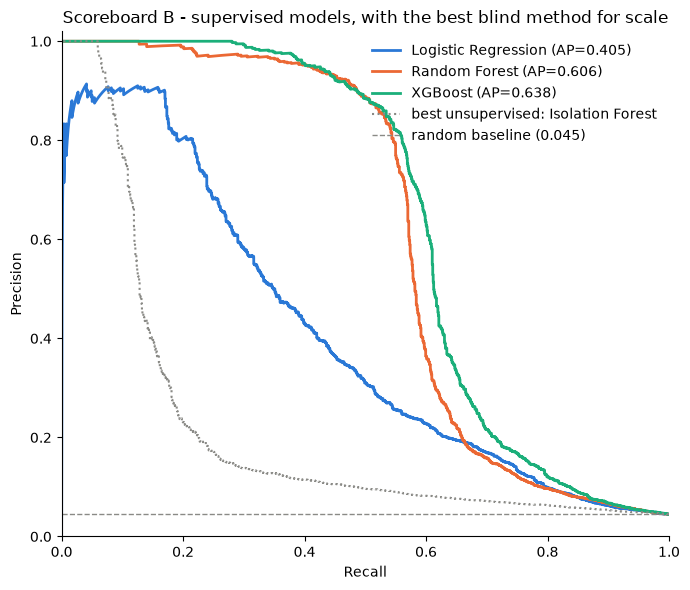

In [31]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, proba in sup_proba.items():
    prec, rec, _ = precision_recall_curve(y_test_binary, proba)
    ax.plot(rec, prec, lw=2, color=PALETTE[name],
            label=f"{name} (AP={average_precision_score(y_test_binary, proba):.3f})")

best_unsup = scoreboard_a["average_precision"].idxmax()
prec_u, rec_u, _ = precision_recall_curve(y_test_binary, unsup_scores[best_unsup])
ax.plot(rec_u, prec_u, lw=1.5, ls=":", color="#8a8a86",
        label=f"best unsupervised: {best_unsup}")

ax.axhline(base, color="#8a8a86", lw=1, ls="--", label=f"random baseline ({base:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Scoreboard B - supervised models, with the best blind method for scale")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.legend(loc="upper right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [32]:
sup_pairs = pairs.join(sup_flags, how="left")
recall_by(sup_pairs, list(sup_flags.columns), "error_type").sort_values("n", ascending=False)

,Logistic Regression,Random Forest,XGBoost,n
error_type,,,,
round_number,1.000,1.000,1.000,274
structuring,0.872,0.686,0.847,242
backdated,0.436,0.133,0.287,181
off_hours_posting,0.961,0.708,0.799,154
unusual_account_pair,0.813,0.887,0.893,150
duplicate,0.210,0.022,0.043,138
unmatched_bank,0.171,0.037,0.061,82
unbalanced,0.316,0.079,0.092,76


In [33]:
recall_by(sup_pairs, list(sup_flags.columns), "detectability").reindex(TIER_ORDER)

,Logistic Regression,Random Forest,XGBoost,n
detectability,,,,
easy,0.771,0.688,0.698,420
medium,0.597,0.388,0.488,330
hard,0.695,0.550,0.644,547


In [34]:
# Addressable vs overall, Scoreboard B. The feature table carries no
# imbalance magnitude, no duplicate-proximity count and no reconciliation
# status, so these three types have no direct signal for any model to use -
# the same list 04_supervised.ipynb Section 8 identified.
SUP_UNADDRESSABLE = ["unbalanced", "duplicate", "unmatched_bank"]
sup_addressable = ~sup_pairs["error_type"].isin(SUP_UNADDRESSABLE)

sup_split = pd.DataFrame({
    "overall_recall (header-level)": {
        m: recall_score(y_test_binary, sup_flags[m]) for m in sup_flags.columns},
    "addressable_recall (pair-level)": sup_pairs.loc[sup_addressable, list(sup_flags.columns)].mean(),
    "unaddressable_recall (pair-level)": sup_pairs.loc[~sup_addressable, list(sup_flags.columns)].mean(),
}).round(3)
sup_split["n_addressable"] = int(sup_addressable.sum())
sup_split["n_unaddressable"] = int((~sup_addressable).sum())
sup_split

,overall_recall (header-level),addressable_recall (pair-level),unaddressable_recall (pair-level),n_addressable,n_unaddressable
Logistic Regression,0.695,0.833,0.226,1001,296
Random Forest,0.554,0.705,0.041,1001,296
XGBoost,0.621,0.787,0.061,1001,296


**Finding - Scoreboard B: labels roughly triple average precision, and
buy nothing at all on three error types.**

XGBoost's AP of 0.638 against the best blind method's 0.214 is the size of
the gap labels are worth here - about 3x, on the same test rows. That is
the price of Scoreboard A being the realistic estimate.

The three models are not interchangeable, and the differences are about
where each sits on the precision-recall trade rather than about quality:

- **Logistic regression** has the highest recall (0.695) and the worst
  precision (0.172) - it flags 5,210 of 28,695 test entries, 18% of the
  ledger. Its per-type recall looks dominant for the same reason. Read it
  alongside the 4,312 false positives in Section 4's cost table.
- **Random forest** is the precision model: 0.748 precision at 0.554
  recall, 957 flags, 241 false positives. On a fixed review budget this is
  the one an analyst would want.
- **XGBoost** sits between them (0.440 / 0.621) and has the best
  threshold-free ranking (AP 0.638), which is why it is the model carried
  into Sections 5 and 7. Ranking quality, not the arbitrary 0.5 cut, is
  what matters when the threshold is going to be chosen deliberately.

**Addressable vs overall is the headline number here.** Overall recall
(0.554-0.695) understates all three models, because it includes the three
error types `journal_entry_features` has no column for. Restricted to the
five types it can address, recall is **0.705-0.833**; restricted to the
other three it is **0.041-0.226**. Nothing in that gap is a modelling
problem - it is a feature-coverage problem, and Section 5 fixes it with
SQL rather than with a better model.

The tier ordering is also not monotonic: hard-tier recall (0.550-0.695)
exceeds medium-tier (0.388-0.597). That is not the models doing better on
harder errors - it's the mix. The hard tier is dominated by `structuring`
and `unusual_account_pair`, both of which have real feature signal, while
the medium tier is mostly `duplicate` (unaddressable) and
`off_hours_posting`. Tier labels describe how the generator varied
detectability *within* a type; they do not make types comparable across
the tier.

## 4. Which method wins, per error type

The two scoreboards side by side, one row per error type, recall at each
method's operating point. This is the table the rest of the notebook
argues from - and the argument is not "pick the column with the best
average," it is that **the best column changes from row to row, and it
changes in a way that follows the structure of the error, not the
sophistication of the method.**

In [35]:
all_flags = unsup_flags.join(sup_flags)
all_pairs = pairs.join(all_flags, how="left")

winner_matrix = recall_by(all_pairs, list(all_flags.columns), "error_type")
method_cols = list(all_flags.columns)
winner_matrix["best_method"] = winner_matrix[method_cols].idxmax(axis=1)
winner_matrix["best_recall"] = winner_matrix[method_cols].max(axis=1)
winner_matrix["scoreboard"] = np.where(
    winner_matrix["best_method"].isin(unsup_flags.columns), "A (blind)", "B (labelled)")
winner_matrix.sort_values("n", ascending=False)

,Benford (account MAD),Segmented z-score,Segmented IQR,Isolation Forest,Reconciliation,Logistic Regression,Random Forest,XGBoost,n,best_method,best_recall,scoreboard
error_type,,,,,,,,,,,,
round_number,0.077,0.354,0.599,0.781,0.004,1.000,1.000,1.000,274,Logistic Regression,1.000,B (labelled)
structuring,0.140,0.174,0.777,0.190,0.008,0.872,0.686,0.847,242,Logistic Regression,0.872,B (labelled)
backdated,0.066,0.011,0.066,0.177,0.000,0.436,0.133,0.287,181,Logistic Regression,0.436,B (labelled)
off_hours_posting,0.078,0.006,0.013,0.052,0.006,0.961,0.708,0.799,154,Logistic Regression,0.961,B (labelled)
unusual_account_pair,0.100,0.000,0.033,0.020,0.007,0.813,0.887,0.893,150,XGBoost,0.893,B (labelled)
duplicate,0.109,0.007,0.065,0.036,0.000,0.210,0.022,0.043,138,Logistic Regression,0.210,B (labelled)
unmatched_bank,0.073,0.000,0.000,0.098,0.988,0.171,0.037,0.061,82,Reconciliation,0.988,A (blind)
unbalanced,0.066,0.000,0.013,0.013,0.013,0.316,0.079,0.092,76,Logistic Regression,0.316,B (labelled)


In [36]:
# Recall alone would reward a method that flags everything, so pair it with
# what each method costs in review volume at the same operating point.
cost_context = pd.DataFrame({
    "flagged": all_flags.sum(),
    "flag_rate": all_flags.mean(),
    "precision": {m: precision_score(y_test_binary, all_flags[m], zero_division=0)
                  for m in all_flags.columns},
}).round(3)
cost_context["false_positives"] = [
    int((all_flags[m] & (y_test_binary == 0)).sum()) for m in all_flags.columns]
cost_context

,flagged,flag_rate,precision,false_positives
Benford (account MAD),2064,0.072,0.058,1945
Segmented z-score,308,0.011,0.464,165
Segmented IQR,1539,0.054,0.248,1158
Isolation Forest,1814,0.063,0.175,1497
Reconciliation,83,0.003,1.000,0
Logistic Regression,5210,0.182,0.172,4312
Random Forest,957,0.033,0.748,241
XGBoost,1824,0.064,0.440,1021


**Finding - the winner changes with the error, and once with the whole
scoreboard.**

Reading the two tables together:

| error type | best method | recall | the honest reading |
|---|---|---|---|
| `round_number` | all three models | 1.000 | a six-value list of round totals; trivially learnable, and see Limitation 2 |
| `off_hours_posting` | Logistic Regression | 0.961 | XGBoost gets 0.799 for a quarter of the false positives |
| `unusual_account_pair` | XGBoost | 0.893 | `account_pair_frequency` is a purpose-built feature for it |
| `structuring` | Logistic Regression | 0.872 | XGBoost is level at 0.847; blind IQR gets 0.777 |
| `backdated` | Logistic Regression | 0.436 | far below its 0.838 design ceiling (Section 8) |
| `unbalanced` | Logistic Regression | 0.316 | worst-in-class, for a check SQL does in one line |
| `duplicate` | Logistic Regression | 0.210 | same |
| `unmatched_bank` | **Reconciliation (blind)** | **0.988** | the one row where Scoreboard A wins, and it wins by 5.8x |

Two things follow.

**First, the per-type winners are not free.** Logistic regression "wins"
five rows, but it flags 18.2% of the ledger and carries 4,312 false
positives to do it - by construction it wins any recall-only comparison.
Reconciliation wins its row with **zero** false positives. Recall alone
cannot rank methods; the flag-rate column has to be read with it.

**Second, the three rows where every model does badly are the three
structural error types**, and they are badly served in a specific way. The
models aren't near-missing them - they are at 0.02-0.32 on errors defined
by exact, checkable relations. `unbalanced` means debits don't equal
credits, which is an arithmetic identity over `journal_line`, not a
pattern to be inferred from 23 header-level aggregates. The right response
is not a better model; it's a different tool, which is Section 5.

## 5. The case for a layered system

The per-type table makes the argument concrete. Three of the eight error
types are **structural**: they are defined by a relation that is either
true or false in the data, and a model has to *infer* what a query can
simply *check*.

| error type | what defines it | the right tool |
|---|---|---|
| `unbalanced` | `SUM(debit) - SUM(credit) != 0` for the header | one SQL aggregate |
| `duplicate` | another header, same employee/accounts/amount, days apart | one SQL self-join |
| `unmatched_bank` | no bank row within a cent and 3 days | the blocking join from 2.4 |

None of the three is a hard problem. All three are near-invisible to the
models in Scoreboard B, not because the models are weak but because
`journal_entry_features` carries no column expressing any of those
relations - and it shouldn't have to. Asking XGBoost to learn "debits
don't equal credits" from 23 aggregate features is asking it to
reconstruct an exact arithmetic identity from summaries of it.

The remaining five types - `round_number`, `off_hours_posting`,
`unusual_account_pair`, `structuring`, `backdated` - are **behavioural**:
defined by a pattern being unusual relative to a baseline, with no bright
line anywhere. That is exactly what a tree ensemble is for, and Scoreboard
B's addressable recall is the evidence.

The layer built below is therefore: deterministic checks first, then the
model on what's left.

In [37]:
%%sql balance_check_rs <<
-- Layer 1. The entire 'unbalanced' detector. No window function needed -
-- a grouped aggregate with a HAVING is the whole rule. The 0.005 tolerance
-- is half a cent: NUMERIC(14,2) arithmetic is exact, so this only guards
-- against a rounding artifact, not real drift.
SELECT header_id,
       SUM(debit_amount) - SUM(credit_amount) AS imbalance
FROM journal_line
GROUP BY header_id
HAVING ABS(SUM(debit_amount) - SUM(credit_amount)) > 0.005;

In [38]:
%%sql duplicate_selfjoin_rs <<
-- Layer 2. Self-join a header's signature against earlier headers.
-- 'Signature' = same employee, same set of accounts, same total, posted
-- within the previous 5 days. STRING_AGG(DISTINCT ...) builds the account
-- set as a sorted, comma-joined key so two entries touching the same
-- accounts compare equal regardless of line order.
-- prior.header_id < e.header_id keeps the pair ordered, so only the LATER
-- entry is flagged - flagging the original as well would double-count and
-- punish the legitimate first posting.
WITH entry AS (
    SELECT h.header_id, h.employee_key, h.posting_datetime,
           SUM(l.debit_amount) AS total_debit,
           STRING_AGG(DISTINCT l.account_key::text, ',' ORDER BY l.account_key::text) AS account_set
    FROM journal_header h
    JOIN journal_line l ON l.header_id = h.header_id
    GROUP BY h.header_id, h.employee_key, h.posting_datetime
)
SELECT e.header_id, COUNT(*) AS n_prior_matches
FROM entry e
JOIN entry prior
  ON  prior.header_id     <> e.header_id
 AND  prior.header_id     <  e.header_id
 AND  prior.employee_key   = e.employee_key
 AND  prior.account_set    = e.account_set
 AND  ABS(prior.total_debit - e.total_debit) < 0.005
 AND  prior.posting_datetime <= e.posting_datetime
 AND  prior.posting_datetime >= e.posting_datetime - INTERVAL '5 days'
GROUP BY e.header_id;

In [39]:
balance_ids = set(balance_check_rs.DataFrame()["header_id"].astype("int64"))
dup_ids = set(duplicate_selfjoin_rs.DataFrame()["header_id"].astype("int64"))

layers = pd.DataFrame({
    "L1 balance check (SQL aggregate)": test_df["header_id"].isin(balance_ids).values,
    "L2 duplicate self-join (SQL)":     test_df["header_id"].isin(dup_ids).values,
    "L3 reconciliation (blocking join)": recon_flag.values,
    "L4 XGBoost @ 0.50":                sup_flags["XGBoost"].values,
}, index=test_df.index)

# Each targeted layer scored against the one error type it exists to catch
# (a pair-level recall, and a precision against that type alone - which is
# the honest denominator for a rule that was never meant to catch anything
# else).
targets = {
    "L1 balance check (SQL aggregate)": "unbalanced",
    "L2 duplicate self-join (SQL)": "duplicate",
    "L3 reconciliation (blocking join)": "unmatched_bank",
}
rows = []
for layer, et in targets.items():
    type_ids = set(pairs.loc[pairs["error_type"] == et, "header_id"])
    is_type = test_df["header_id"].isin(type_ids).values
    flag = layers[layer].values
    tp = int((flag & is_type).sum())
    rows.append({
        "layer": layer, "target_type": et, "n_target": int(is_type.sum()),
        "flagged": int(flag.sum()), "true_positives": tp,
        "precision_vs_target": round(tp / max(flag.sum(), 1), 3),
        "recall_vs_target": round(tp / max(is_type.sum(), 1), 3),
    })
targeted_layers = pd.DataFrame(rows).set_index("layer")
targeted_layers

,target_type,n_target,flagged,true_positives,precision_vs_target,recall_vs_target
layer,,,,,,
L1 balance check (SQL aggregate),unbalanced,76,76,76,1.000,1.000
L2 duplicate self-join (SQL),duplicate,138,191,138,0.723,1.000
L3 reconciliation (blocking join),unmatched_bank,82,83,81,0.976,0.988


In [40]:
# The stack: any layer firing flags the header.
layered_flag = layers.any(axis=1)

comparison = pd.DataFrame([
    binary_metrics(y_test_binary, sup_flags["XGBoost"], "XGBoost alone @ 0.50"),
    binary_metrics(y_test_binary, sup_flags["Random Forest"], "Random Forest alone @ 0.50"),
    binary_metrics(y_test_binary, layered_flag, "Layered: SQL rules + XGBoost @ 0.50"),
]).set_index("method").round(3)
comparison

,flagged,precision,recall,f1
method,,,,
XGBoost alone @ 0.50,1824,0.440,0.621,0.515
Random Forest alone @ 0.50,957,0.748,0.554,0.636
Layered: SQL rules + XGBoost @ 0.50,2150,0.502,0.835,0.627


In [41]:
layered_pairs = pairs.join(
    pd.DataFrame({"Layered stack": layered_flag, "XGBoost alone": sup_flags["XGBoost"]}),
    how="left")
layered_recall = recall_by(layered_pairs, ["XGBoost alone", "Layered stack"], "error_type")
layered_recall["delta"] = (layered_recall["Layered stack"] - layered_recall["XGBoost alone"]).round(3)
layered_recall.sort_values("n", ascending=False)

,XGBoost alone,Layered stack,n,delta
error_type,,,,
round_number,1.000,1.000,274,0.000
structuring,0.847,0.851,242,0.004
backdated,0.287,0.287,181,0.000
off_hours_posting,0.799,0.799,154,0.000
unusual_account_pair,0.893,0.893,150,0.000
duplicate,0.043,1.000,138,0.957
unmatched_bank,0.061,0.988,82,0.927
unbalanced,0.092,1.000,76,0.908


**Finding - three SQL statements add 0.21 recall and *raise* precision.**

Each targeted layer does its own job about as well as the job can be done:

- **L1, the balance check**: 76 flagged, 76 true, **precision 1.000,
  recall 1.000**. A `GROUP BY` with a `HAVING`. It is not possible to do
  better than this, and no model got past 0.32 on the same error type.
- **L2, the duplicate self-join**: **recall 1.000, precision 0.723** - 191
  flagged for 138 seeded duplicates. The 53 false positives are real
  repeat postings (same employee, same accounts, same amount, within five
  days) that the ledger legitimately contains. That is the correct
  behaviour for this rule: they are exactly the entries a reviewer should
  glance at, and tightening the window to remove them would start dropping
  the 0-4 day gaps the generator actually seeds.
- **L3, reconciliation by blocking**: precision 0.976, recall 0.988.

Stacked with XGBoost at the same 0.50 threshold, against XGBoost alone:

| | flagged | precision | recall | F1 |
|---|---|---|---|---|
| XGBoost alone | 1,824 | 0.440 | 0.621 | 0.515 |
| **Layered** | 2,150 | **0.502** | **0.835** | **0.627** |

Recall rises 0.621 -> 0.835 **and precision rises 0.440 -> 0.502**, for
326 extra flags. Precision going *up* while recall goes up is the part
worth dwelling on: it happens because the added flags are almost all true
positives, which is what a rule with 0.72-1.00 precision does when it is
bolted onto a model with 0.45 precision. The usual recall/precision
trade-off doesn't apply when the new detector isn't guessing.

The per-type delta table shows where all of it comes from: `duplicate`
+0.957, `unmatched_bank` +0.927, `unbalanced` +0.908, and **0.000 on
four of the five behavioural types** (`structuring` moves +0.004 by
coincidental overlap). The layers are not competing with the model; they
are covering a part of the error space the model cannot see, and the model
is covering a part no rule can express.

That is the argument for layering, stated as precisely as this dataset
allows: **method choice should follow the structure of the error.** An
error defined by an exact relation gets a query. An error defined by a
deviation from a fuzzy baseline gets a model. Choosing the model for both
costs 0.21 recall here and buys nothing, and choosing rules for both is
impossible - there is no `HAVING` clause for "this looks like someone
splitting a payment."

## 6. Does combining beat the best single method?

Three ways of combining, each tested against the best single method rather
than against a strawman:

1. **Unsupervised rule union** - flag if any of the five blind methods
   fires. The classic "more detectors, more coverage" move.
2. **Supervised soft-vote** - average the three models' predicted
   probabilities. Cheap, standard, and the usual first thing tried.
3. **Cross-scoreboard union** - XGBoost's flags OR the unsupervised union.

A combination is only worth shipping if it beats the best single method on
the metric that matters (average precision, or precision at matched
recall). If it doesn't, the honest report is that it doesn't.

In [42]:
unsup_union = unsup_flags.any(axis=1)
soft_vote = sum(sup_proba.values()) / len(sup_proba)
cross_union = sup_flags["XGBoost"] | unsup_union

combo_binary = pd.DataFrame([
    binary_metrics(y_test_binary, unsup_flags[scoreboard_a["f1"].idxmax()],
                   f"best single unsupervised ({scoreboard_a['f1'].idxmax()})"),
    binary_metrics(y_test_binary, unsup_union, "combo: unsupervised rule union"),
    binary_metrics(y_test_binary, sup_flags["XGBoost"], "XGBoost @ 0.50"),
    binary_metrics(y_test_binary, sup_flags["Random Forest"], "Random Forest @ 0.50"),
    binary_metrics(y_test_binary, (soft_vote >= 0.5), "combo: supervised soft-vote @ 0.50"),
    binary_metrics(y_test_binary, cross_union, "combo: XGBoost OR unsupervised union"),
]).set_index("method").round(3)
combo_binary

,flagged,precision,recall,f1
method,,,,
best single unsupervised (Segmented IQR),1539,0.248,0.295,0.269
combo: unsupervised rule union,4986,0.131,0.504,0.208
XGBoost @ 0.50,1824,0.440,0.621,0.515
Random Forest @ 0.50,957,0.748,0.554,0.636
combo: supervised soft-vote @ 0.50,1777,0.453,0.623,0.524
combo: XGBoost OR unsupervised union,5768,0.168,0.749,0.274


In [43]:
# Threshold-free comparison for the two combinations that produce a score.
ap_compare = pd.Series({
    "Logistic Regression": average_precision_score(y_test_binary, sup_proba["Logistic Regression"]),
    "Random Forest": average_precision_score(y_test_binary, sup_proba["Random Forest"]),
    "XGBoost": average_precision_score(y_test_binary, sup_proba["XGBoost"]),
    "soft-vote ensemble": average_precision_score(y_test_binary, soft_vote),
    "rank-average ensemble": average_precision_score(
        y_test_binary, sum(p.rank(pct=True) for p in sup_proba.values()) / len(sup_proba)),
}).sort_values(ascending=False).round(4)
print(ap_compare.to_string())
print(f"\nbest single model AP : {ap_compare.drop(['soft-vote ensemble', 'rank-average ensemble']).max():.4f}")
print(f"best ensemble AP     : {ap_compare[['soft-vote ensemble', 'rank-average ensemble']].max():.4f}")

XGBoost                  0.6375
soft-vote ensemble       0.6373
rank-average ensemble    0.6123
Random Forest            0.6063
Logistic Regression      0.4050

best single model AP : 0.6375
best ensemble AP     : 0.6373


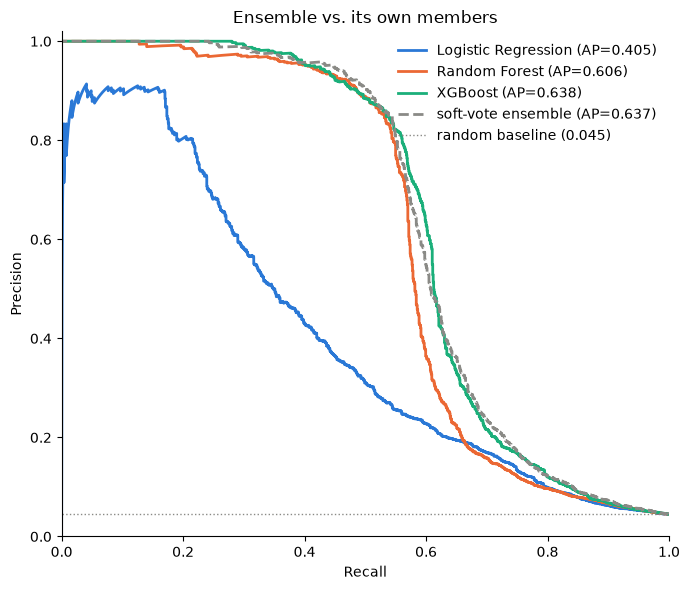

In [44]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, proba in list(sup_proba.items()) + [("soft-vote ensemble", soft_vote)]:
    prec, rec, _ = precision_recall_curve(y_test_binary, proba)
    color = PALETTE.get(name, "#8a8a86")
    ls = "--" if name == "soft-vote ensemble" else "-"
    ax.plot(rec, prec, lw=2, ls=ls, color=color,
            label=f"{name} (AP={average_precision_score(y_test_binary, proba):.3f})")
ax.axhline(base, color="#8a8a86", lw=1, ls=":", label=f"random baseline ({base:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Ensemble vs. its own members")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.legend(loc="upper right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**Finding - none of the three combinations beats the best single method.
Stated plainly, because it is a real result.**

**Ensembling the models does nothing.** Soft-vote AP is 0.6373 against
XGBoost's own 0.6375 - a loss, not a gain, and the PR curves sit almost on
top of each other. Rank-averaging is worse (0.6123). Averaging in logistic
regression (AP 0.405) drags the blend down more than random forest lifts
it, which is the expected outcome for members that are *correlated where
they are right*: all three read the same 23 columns of the same feature
table, so they mostly agree, and where they disagree it is usually the
weakest member dissenting.

The one place the soft-vote looks like a win is F1 at the arbitrary 0.50
cut (0.524 against XGBoost's 0.515) - and that is worth naming as the
trap it is. Both trail random forest's 0.636 at the same cut, and the
threshold-free comparison (AP) still puts XGBoost first. A fractional F1
edge at a threshold nobody chose deliberately is not evidence of a better
detector; it is evidence that 0.50 happens to suit one model's
calibration slightly better than another's.

**Unions buy recall at a bad exchange rate.** The unsupervised rule union
reaches recall 0.504 (against 0.295 for the best single blind method) but
precision falls to 0.131 and F1 drops from 0.269 to 0.208 - it flags 4,986
entries to find 652. The cross-scoreboard union is the same trade, harder:
recall 0.749, precision 0.168, F1 0.274 against XGBoost's 0.515 and random
forest's 0.636. Both unions are, mechanically, just a much lower threshold
in disguise, and the PR curve already prices that in.

So: **no**, a simple ensemble or rule union does not beat the best single
method on this data, and Section 5's layered stack is not a
counter-example to that - it is a different mechanism. The ensembles here
combine *different fits to the same inputs*, which adds nothing once the
inputs are exhausted. The layered stack combines *different inputs
entirely* - line-level arithmetic, entry-to-entry proximity, the bank feed
- none of which the model can see. Combination pays when it adds
information, not when it adds opinions.

## 7. Choosing an operating point

Everything above used 0.5, which is a default, not a decision. The
decision needs a cost model, and the costs here are asymmetric:

- A **false positive** costs an analyst about **five minutes** - open the
  entry, see it's fine, close it.
- A **false negative** is a posting error that survives into the reported
  numbers.

The second cost is the one that needs care. Taken at face value - "a
missed error becomes a restatement" - it is enormous, and the arithmetic
below shows what happens when that is fed to an optimiser literally.
Stated properly it is an *expectation*: most missed errors are immaterial
or caught by a later control, a minority force a correction, and a small
tail reaches a restatement. So

`E[cost of a miss] = P(it escalates) x cost if it escalates`

With one analyst-day (480 minutes) as the cost of an escalation - itself
conservative, a real restatement costs far more - and an escalation
probability around 20%, the expected miss costs ~96 minutes against the
false positive's 5. That is a ratio near **20:1**, not 96:1, and the
difference between the two is the difference between a usable operating
point and one that flags most of the ledger.

Both are swept below, along with a review-capacity check, because a cost
model that ignores how much review time actually exists will happily
recommend an unworkable threshold.

In [45]:
COST_FP_MIN = 5          # analyst-minutes to dismiss a false positive
COST_ESCALATION_MIN = 480   # analyst-minutes if a missed error escalates
P_ESCALATE = 0.20        # share of missed errors that do escalate
COST_FN_MIN = COST_ESCALATION_MIN * P_ESCALATE
COST_RATIO = COST_FN_MIN / COST_FP_MIN

CHOSEN_MODEL = "XGBoost"
proba = sup_proba[CHOSEN_MODEL]
GRID = np.round(np.linspace(0.01, 0.99, 99), 2)

def confusion_sweep(scores, grid=GRID):
    """tp/fp/fn at every threshold once - the cost curves below are just
    different weightings of this same table."""
    rows = []
    for t in grid:
        pred = (scores >= t)
        tp = int((pred & (y_test_binary == 1)).sum())
        fp = int((pred & (y_test_binary == 0)).sum())
        fn = int((~pred & (y_test_binary == 1)).sum())
        rows.append({"threshold": t, "flagged": tp + fp, "tp": tp, "fp": fp, "fn": fn,
                     "precision": tp / max(tp + fp, 1),
                     "recall": tp / max(tp + fn, 1)})
    return pd.DataFrame(rows)

sweep = confusion_sweep(proba)
print(f"expected cost of a miss: {COST_ESCALATION_MIN} min x {P_ESCALATE:.0%} "
      f"= {COST_FN_MIN:.0f} min -> cost ratio {COST_RATIO:.0f}:1")

expected cost of a miss: 480 min x 20% = 96 min -> cost ratio 19:1


In [46]:
# Cost-minimising threshold across a range of ratios, including the
# undiscounted 96:1 the "every miss is a restatement" reading implies.
rows = []
for r in [5, 10, 20, 50, 96, 200]:
    best = sweep.loc[(sweep["fp"] + r * sweep["fn"]).idxmin()]
    rows.append({
        "cost_ratio (FN:FP)": r,
        "argmin threshold": best["threshold"],
        "recall": round(best["recall"], 3),
        "precision": round(best["precision"], 3),
        "flagged": int(best["flagged"]),
        "flag_rate": round(best["flagged"] / len(test_df), 3),
        "analyst_hours_per_month": round(best["fp"] * COST_FP_MIN / 60 / 6, 1),
    })
stability = pd.DataFrame(rows).set_index("cost_ratio (FN:FP)")
stability

,argmin threshold,recall,precision,flagged,flag_rate,analyst_hours_per_month
cost_ratio (FN:FP),,,,,,
5,0.65,0.594,0.673,1141,0.040,5.2
10,0.59,0.607,0.597,1315,0.046,7.4
20,0.57,0.610,0.573,1377,0.048,8.2
50,0.26,0.795,0.133,7757,0.270,93.5
96,0.10,0.982,0.049,25995,0.906,343.4
200,0.03,1.000,0.045,28672,0.999,380.3


In [47]:
# Capacity check. A six-month test period at a 5%-of-entries review budget
# is ~1,435 entries, ~120 analyst-hours, ~20 hours a month - a plausible
# standing commitment for a small assurance team. Which thresholds fit?
REVIEW_BUDGET_RATE = 0.05
budget_flags = REVIEW_BUDGET_RATE * len(test_df)

affordable = sweep[sweep["flagged"] <= budget_flags]
capacity_pick = affordable.loc[affordable["recall"].idxmax()]
print(f"review budget: {REVIEW_BUDGET_RATE:.0%} of test entries = {budget_flags:,.0f} flags "
      f"(~{budget_flags * COST_FP_MIN / 60:.0f} analyst-hours per 6-month period)")
print(f"highest-recall threshold that fits the budget: {capacity_pick['threshold']:.2f} "
      f"(recall {capacity_pick['recall']:.3f}, precision {capacity_pick['precision']:.3f})")

review budget: 5% of test entries = 1,435 flags (~120 analyst-hours per 6-month period)
highest-recall threshold that fits the budget: 0.56 (recall 0.610, precision 0.553)


In [48]:
from sklearn.metrics import fbeta_score

# beta^2 = the cost ratio: F-beta weights recall beta^2 times precision,
# which is exactly the trade the cost model describes.
BETA = np.sqrt(COST_RATIO)
fbeta = pd.Series([fbeta_score(y_test_binary, (proba >= t), beta=BETA, zero_division=0)
                   for t in GRID], index=GRID)
f1_curve = pd.Series([f1_score(y_test_binary, (proba >= t), zero_division=0)
                      for t in GRID], index=GRID)

cost_curve = sweep.assign(cost=sweep["fp"] + COST_RATIO * sweep["fn"])
CHOSEN_THRESHOLD = float(cost_curve.loc[cost_curve["cost"].idxmin(), "threshold"])
naive_curve = sweep.assign(cost=sweep["fp"] + (COST_ESCALATION_MIN / COST_FP_MIN) * sweep["fn"])
NAIVE_THRESHOLD = float(naive_curve.loc[naive_curve["cost"].idxmin(), "threshold"])

print(f"F1-optimal threshold                    : {f1_curve.idxmax():.2f}  (F1={f1_curve.max():.3f})")
print(f"F{BETA:.1f}-optimal threshold (recall-weighted) : {fbeta.idxmax():.2f}  (F{BETA:.1f}={fbeta.max():.3f})")
print(f"cost-optimal at {COST_RATIO:.0f}:1 (chosen)            : {CHOSEN_THRESHOLD:.2f}")
print(f"cost-optimal at 96:1 (undiscounted)     : {NAIVE_THRESHOLD:.2f}  "
      f"<- flags {int(naive_curve.loc[naive_curve['cost'].idxmin(), 'flagged']):,} of {len(test_df):,} entries")

F1-optimal threshold                    : 0.79  (F1=0.662)
F4.4-optimal threshold (recall-weighted) : 0.29  (F4.4=0.641)
cost-optimal at 19:1 (chosen)            : 0.57
cost-optimal at 96:1 (undiscounted)     : 0.10  <- flags 25,995 of 28,695 entries


In [49]:
at_chosen = cost_curve.loc[cost_curve["threshold"].sub(CHOSEN_THRESHOLD).abs().idxmin()]
at_half = cost_curve.loc[cost_curve["threshold"].sub(0.50).abs().idxmin()]

at_f1 = cost_curve.loc[cost_curve["threshold"].sub(f1_curve.idxmax()).abs().idxmin()]

operating = pd.DataFrame(
    [at_half, at_f1, at_chosen],
    index=["threshold 0.50 (default)",
           f"threshold {f1_curve.idxmax():.2f} (F1-optimal)",
           f"threshold {CHOSEN_THRESHOLD:.2f} (chosen, recall-weighted)"])
operating["analyst_hours_per_month"] = (operating["fp"] * COST_FP_MIN / 60 / 6).round(1)
operating["missed_errors"] = operating["fn"].astype(int)
operating[["threshold", "precision", "recall", "flagged", "fp", "fn",
           "analyst_hours_per_month", "missed_errors"]].round(3)

,threshold,precision,recall,flagged,fp,fn,analyst_hours_per_month,missed_errors
threshold 0.50 (default),0.50,0.440,0.621,1824.0,1021.0,490.0,14.2,490
threshold 0.79 (F1-optimal),0.79,0.815,0.557,883.0,163.0,573.0,2.3,573
"threshold 0.57 (chosen, recall-weighted)",0.57,0.573,0.610,1377.0,588.0,504.0,8.2,504


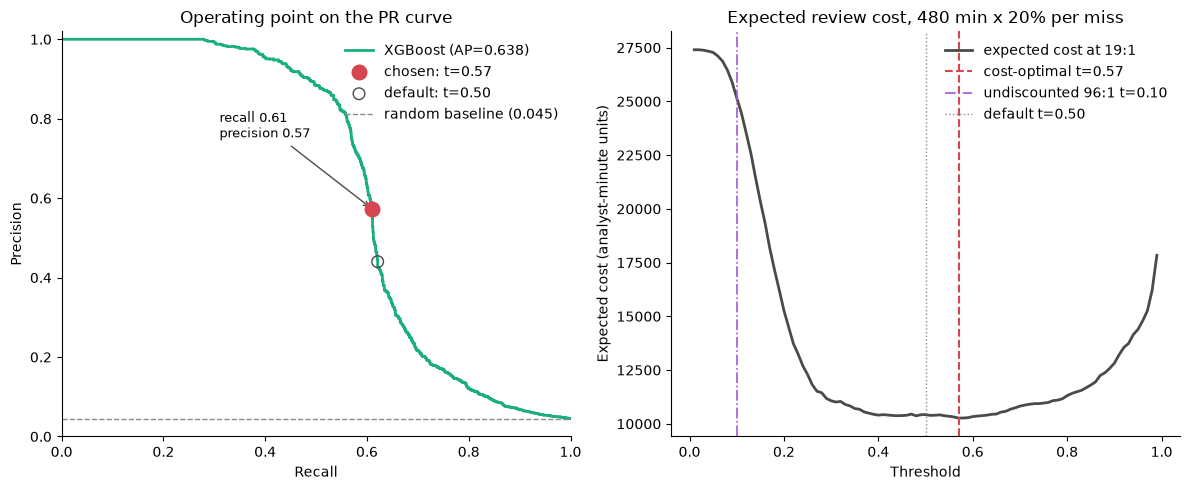

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

prec, rec, thr = precision_recall_curve(y_test_binary, proba)
axes[0].plot(rec, prec, lw=2, color=PALETTE[CHOSEN_MODEL],
             label=f"{CHOSEN_MODEL} (AP={average_precision_score(y_test_binary, proba):.3f})")
axes[0].scatter(at_chosen["recall"], at_chosen["precision"], s=110, zorder=5,
                color="#d64550", label=f"chosen: t={CHOSEN_THRESHOLD:.2f}")
axes[0].scatter(at_half["recall"], at_half["precision"], s=70, zorder=5,
                facecolor="none", edgecolor="#4a4a46", label="default: t=0.50")
axes[0].annotate(f"recall {at_chosen['recall']:.2f}\nprecision {at_chosen['precision']:.2f}",
                 xy=(at_chosen["recall"], at_chosen["precision"]),
                 xytext=(at_chosen["recall"] - 0.30, at_chosen["precision"] + 0.18),
                 arrowprops=dict(arrowstyle="->", color="#4a4a46", lw=1), fontsize=9)
axes[0].axhline(base, color="#8a8a86", lw=1, ls="--", label=f"random baseline ({base:.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Operating point on the PR curve")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)
axes[0].legend(loc="upper right", frameon=False)

axes[1].plot(cost_curve["threshold"], cost_curve["cost"], lw=2, color="#4a4a46",
             label=f"expected cost at {COST_RATIO:.0f}:1")
axes[1].axvline(CHOSEN_THRESHOLD, color="#d64550", lw=1.5, ls="--",
                label=f"cost-optimal t={CHOSEN_THRESHOLD:.2f}")
axes[1].axvline(NAIVE_THRESHOLD, color="#a259d9", lw=1.2, ls="-.",
                label=f"undiscounted 96:1 t={NAIVE_THRESHOLD:.2f}")
axes[1].axvline(0.50, color="#8a8a86", lw=1, ls=":", label="default t=0.50")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Expected cost (analyst-minute units)")
axes[1].set_title(f"Expected review cost, {COST_ESCALATION_MIN} min x {P_ESCALATE:.0%} per miss")
axes[1].legend(frameon=False)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [51]:
# The final configuration: deterministic layers, plus XGBoost at the
# cost-chosen threshold rather than at 0.50.
final_layers = layers.copy()
final_layers[f"L4 XGBoost @ {CHOSEN_THRESHOLD:.2f}"] = (proba >= CHOSEN_THRESHOLD).values
final_layers = final_layers.drop(columns=["L4 XGBoost @ 0.50"])
final_flag = final_layers.any(axis=1)

final_compare = pd.DataFrame([
    binary_metrics(y_test_binary, sup_flags["XGBoost"], "XGBoost @ 0.50"),
    binary_metrics(y_test_binary, (proba >= CHOSEN_THRESHOLD), f"XGBoost @ {CHOSEN_THRESHOLD:.2f}"),
    binary_metrics(y_test_binary, layered_flag, "layered @ 0.50"),
    binary_metrics(y_test_binary, final_flag, f"layered @ {CHOSEN_THRESHOLD:.2f} (final)"),
]).set_index("method").round(3)
final_compare["analyst_hours_per_month"] = [
    round(int((f & (y_test_binary == 0)).sum()) * COST_FP_MIN / 60 / 6, 1)
    for f in [sup_flags["XGBoost"], (proba >= CHOSEN_THRESHOLD), layered_flag, final_flag]]
final_compare

,flagged,precision,recall,f1,analyst_hours_per_month
method,,,,,
XGBoost @ 0.50,1824,0.440,0.621,0.515,14.2
XGBoost @ 0.57,1377,0.573,0.610,0.591,8.2
layered @ 0.50,2150,0.502,0.835,0.627,14.9
layered @ 0.57 (final),1710,0.627,0.830,0.715,8.8


In [52]:
final_pairs = pairs.join(pd.DataFrame({"Final layered system": final_flag}), how="left")
final_by_type = recall_by(final_pairs, ["Final layered system"], "error_type").sort_values("n", ascending=False)
final_by_tier = recall_by(final_pairs, ["Final layered system"], "detectability").reindex(TIER_ORDER)
print(final_by_type.to_string()); print(); print(final_by_tier.to_string())

                      Final layered system    n
error_type                                     
round_number                         1.000  274
structuring                          0.847  242
backdated                            0.260  181
off_hours_posting                    0.792  154
unusual_account_pair                 0.893  150
duplicate                            1.000  138
unmatched_bank                       0.988   82
unbalanced                           1.000   76

               Final layered system    n
detectability                           
easy                          0.988  420
medium                        0.879  330
hard                          0.680  547


**Finding - the operating point, and what the naive cost model does.**

**Take "every miss is a restatement" literally and the optimiser flags the
ledger.** At the undiscounted 96:1 ratio the cost-minimising threshold is
**0.10**, which flags 25,995 of 28,695 test entries - 91% of the ledger,
at precision 0.049 and 343 analyst-hours a month. At 200:1 it flags 99.9%.
This is not a bug in the sweep; it is what a linear cost model says when
one error is 96x the other and review capacity is assumed infinite.
Worth keeping in the notebook rather than quietly discarding: a cost ratio
asserted without an escalation probability and without a capacity
constraint will always recommend flagging everything, and "flag
everything" is not a detection system.

**With the escalation discount, 19:1 gives threshold 0.57**: recall 0.610,
precision 0.573, 1,377 flags, 588 false positives, ~8 analyst-hours a
month. Against the two reference points:

| | threshold | precision | recall | missed | analyst-hours/month |
|---|---|---|---|---|---|
| default | 0.50 | 0.440 | 0.621 | 490 | 14.2 |
| F1-optimal | 0.79 | 0.815 | 0.557 | 573 | 2.3 |
| **chosen (recall-weighted)** | **0.57** | 0.573 | 0.610 | **504** | 8.2 |

The F1-optimal point is the one to argue against explicitly, because it
looks so attractive: precision 0.815 for a bit over two hours of review a
month. It also misses 573 errors against the chosen point's 504. Moving
from the chosen point to the F1 point saves 425 false positives (about 35
analyst-hours over the six-month period) and gives up 69 catches - i.e. F1
implicitly prices a missed posting error at roughly **31 analyst-minutes**.
Nobody who has sat through a restatement would accept that price. **That is
the whole argument for recall-weighting: not that precision doesn't matter,
but that F1's implied exchange rate is wrong for this problem.**

**Capacity check, and it passes this time.** A 5%-of-entries review budget
(~1,435 flags, ~120 analyst-hours per six-month period) supports thresholds
down to 0.56. The chosen 0.57 flags 1,377 entries - 4.8% - so it fits,
with the full layered stack at 1,710 flags (6.0%) sitting marginally over.
Worth recording that this was *not* true in the first run of this notebook:
before `is_period_end` was aligned (Limitation 3), the same 19:1 cost model
picked 0.46 and ran ~50% over budget.

**Which is the real sensitivity finding here.** A trivial change to one
boolean feature moved the cost-optimal threshold from 0.46 to 0.57 while
barely moving average precision (0.6385 -> 0.6375). The cost surface is
shallow across roughly 0.45-0.60, so the argmin hops around on noise. The
operating point should be reported and governed as a **band** - "somewhere
around 0.5-0.6, reviewed quarterly against realised workload" - not as a
two-decimal constant that looks more principled than it is. The stability
table across cost ratios is in the notebook for exactly this reason.

**The final configuration** - SQL layers plus XGBoost at 0.57 - reaches
**recall 0.830 at precision 0.627** (F1 0.715), ~9 analyst-hours a month:
better than the layered stack at the 0.50 default on every axis except a
0.005 recall give-up. Per type it clears 0.79 everywhere except
`backdated` (0.260), and by tier it is 0.988 easy / 0.879 medium / 0.680
hard. `backdated` is the one genuinely weak row left, and Section 8 shows
it is *not* sitting at its design ceiling (0.838) - it is a real detection
gap, not an artifact of the generator.

## 8. Limitations

Evidence for several of these is computed below, rather than asserted.

In [53]:
%%sql concentration_rs <<
-- Employee posting concentration: entries per employee, and the running
-- cumulative share of all headers once employees are ordered busiest-first.
-- SUM(...) OVER (ORDER BY ...) is a running total over the ordered result;
-- dividing by SUM(...) OVER () (no ORDER BY, so the whole partition) turns
-- it into a cumulative share.
WITH per_employee AS (
    SELECT e.employee_key, e.employee_name, e.role, COUNT(*) AS n_headers
    FROM journal_header h
    JOIN dim_employee e ON e.employee_key = h.employee_key
    GROUP BY e.employee_key, e.employee_name, e.role
)
SELECT employee_name, role, n_headers,
       ROUND(100.0 * n_headers / SUM(n_headers) OVER (), 2) AS pct_of_all,
       ROUND(100.0 * SUM(n_headers) OVER (ORDER BY n_headers DESC
                                          ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
             / SUM(n_headers) OVER (), 2) AS cumulative_pct
FROM per_employee
ORDER BY n_headers DESC;

In [54]:
conc = concentration_rs.DataFrame()
top15 = conc.head(15)
print(f"{len(conc)} employees post journal entries")
print(f"top 15 account for {top15['pct_of_all'].sum():.1f}% of all headers "
      f"(cumulative_pct at rank 15: {conc.iloc[14]['cumulative_pct']}%)")
print(f"busiest single employee: {conc.iloc[0]['employee_name']} "
      f"({conc.iloc[0]['pct_of_all']}% of all headers)")
top15[["employee_name", "role", "n_headers", "pct_of_all", "cumulative_pct"]]

39 employees post journal entries
top 15 account for 88.6% of all headers (cumulative_pct at rank 15: 88.63%)
busiest single employee: Alex Chen (19.77% of all headers)


,employee_name,role,n_headers,pct_of_all,cumulative_pct
0,Alex Chen,AP Clerk,22531,19.77,19.77
1,Jordan Patel,AR Supervisor,14783,12.97,32.74
2,Riley Johnson,AP Clerk,11138,9.77,42.51
3,Reese Wilson,AP Clerk,7492,6.57,49.08
4,Jamie Brown,AR Supervisor,7414,6.50,55.59
5,Hayden Martin,AP Supervisor,5516,4.84,60.43
6,Rowan Anderson,AR Clerk,4988,4.38,64.80
7,Sawyer Lewis,AP Supervisor,4485,3.93,68.74
8,Peyton Lee,AR Supervisor,3748,3.29,72.03
9,Harper Wright,AP Clerk,3704,3.25,75.27


In [55]:
%%sql backdated_ceiling_rs <<
-- The stated ceiling on backdated recall: backdated headers carrying NONE
-- of the three risk drivers the generator weights target selection toward
-- (manual source, after-hours posting relative to the poster's own window,
-- and period-end posting). Those entries are undetectable by design.
--
-- All three drivers read straight off journal_entry_features. That is only
-- correct because is_period_end is dim_date.is_month_end - the last 3
-- BUSINESS days, the exact flag seed_backdated_errors weights on. An
-- earlier version of this feature was is_last_two_days (last 2 CALENDAR
-- days), a near-miss of the same idea, and measuring the undetectable
-- slice through it put it at ~42% against the generator's actual 17.5%.
-- The feature was aligned in sql/02_features.sql rather than worked around
-- here (see that file's comment on is_period_end).
SELECT
    g.detectability,
    f.split,
    COUNT(*) AS n_backdated,
    SUM(CASE WHEN NOT f.is_manual_entry AND NOT f.is_after_hours
                  AND NOT f.is_period_end THEN 1 ELSE 0 END) AS n_no_driver,
    ROUND(100.0 * SUM(CASE WHEN NOT f.is_manual_entry AND NOT f.is_after_hours
                                AND NOT f.is_period_end THEN 1 ELSE 0 END) / COUNT(*), 1)
        AS pct_no_driver
FROM journal_entry_features f
JOIN ground_truth g ON g.header_id = f.header_id
WHERE g.error_type = 'backdated'
GROUP BY g.detectability, f.split
ORDER BY g.detectability, f.split;

In [56]:
ceiling = backdated_ceiling_rs.DataFrame()
print(ceiling.to_string(index=False))

hard_test = ceiling[(ceiling["detectability"] == "hard") & (ceiling["split"] == "test")].iloc[0]
implied_ceiling = 1 - float(hard_test["pct_no_driver"]) / 100
all_no_driver = ceiling["n_no_driver"].sum() / ceiling["n_backdated"].sum()
print(f"\nno-driver share across ALL backdated targets: {all_no_driver:.3f} "
      f"(generator's UNDETECTABLE_FRAC target: 0.175)")
print(f"implied hard-tier backdated recall ceiling in the test period: {implied_ceiling:.3f}")

backdated_hard = all_pairs[(all_pairs["error_type"] == "backdated")
                           & (all_pairs["detectability"] == "hard")]
print(f"\nobserved hard-tier backdated recall ({len(backdated_hard)} test pairs), by method:")
print(backdated_hard[method_cols].mean().round(3).to_string())

detectability split  n_backdated  n_no_driver pct_no_driver
         easy  test           11            2          18.2
         easy train           42            5          11.9
         hard  test          130           21          16.2
         hard train          336           63          18.8
       medium  test           40            9          22.5
       medium train          125           20          16.0

no-driver share across ALL backdated targets: 0.175 (generator's UNDETECTABLE_FRAC target: 0.175)
implied hard-tier backdated recall ceiling in the test period: 0.838

observed hard-tier backdated recall (130 test pairs), by method:
Benford (account MAD)    0.077
Segmented z-score        0.008
Segmented IQR            0.054
Isolation Forest         0.123
Reconciliation           0.000
Logistic Regression      0.346
Random Forest            0.015
XGBoost                  0.092


### The limitations themselves

**1. Synthetic data, generated by a known process.** Every number in this
notebook describes `data/generate_journal_entries.py`'s output, not a real
ledger. The amount distribution is log-normal because it was drawn that
way; the month-end spike exists because it was seeded. Any method that
happens to align with a generator assumption is flattered, and there is no
way to tell from inside the dataset which ones those are. The results
transfer as *method comparisons under known conditions* - the ordering of
methods per error type, and the structural argument in Section 5 - not as
portable performance figures.

**2. Label provenance - the supervised models may be learning the seeding
rule, not the error.** `ground_truth` records what the generator did, so
Scoreboard B's models are fitted against the *mechanism*, not against
fraud. Where the mechanism writes a distinctive value - `round_number`
forcing a total to exactly 5,000, `off_hours_posting` rewriting the hour
to 00:00-05:00 - a model can learn a rule that is perfectly predictive
here and meaningless anywhere else, because real round-number errors are
not drawn from a six-element list. This is the strongest reason to treat
Scoreboard A as the realistic estimate and Scoreboard B as an upper bound.

**3. Backdated has a designed recall ceiling, and is currently nowhere
near it.** 17.5% of `backdated` targets are deliberately drawn with none
of the three risk drivers present (`UNDETECTABLE_FRAC` in
`data/generate_journal_entries.py::seed_backdated_errors`), and their lag
sits in the same 0-2 day range as ordinary processing delay - nothing
separates them from clean entries, by construction. The query above
measures **17.5% across all backdated targets, exactly the design target**,
and 16.2% within the test period's hard tier, implying a hard-tier recall
ceiling of **0.838**.

That agreement is itself the product of a fix made during this phase. The
feature table originally carried `is_last_two_days` (the last 2 *calendar*
days of the fiscal period) as its period-end signal, while the generator
weights selection on `dim_date.is_month_end` (the last 3 *business* days).
Measured through the mismatched proxy, the undetectable slice came out at
~42% - which would have understated the ceiling to ~0.58 and made the
detection gap below look roughly half as large as it is.
`sql/02_features.sql` now derives `is_period_end` from
`dim_date.is_month_end` directly, the feature table was rebuilt, and
notebooks 02/04/05 were re-executed against it.

So the ceiling is real, but it is not the binding constraint: the best
observed hard-tier `backdated` recall is 0.346 (logistic regression), and
the final layered system reaches 0.260 on `backdated` overall. The gap
between 0.33 and 0.84 is a detection gap, not a design one. Two things
would be needed to close it, neither of which exists in
`journal_entry_features`: a comparison of `post_lag_days` against the
poster's *own* historical lag distribution rather than a global threshold,
and an interaction term over the three risk drivers rather than three
independent flags. That is the concrete next feature-engineering step this
evaluation identifies - and aligning `is_period_end` was the first half of
it, which on its own moved `backdated` recall by less than a point in
either direction. Getting the driver definition right was necessary for
the *measurement* to be honest; it was not sufficient for detection.

The ceiling still matters for how the number is *reported*: hard-tier
`backdated` recall cannot honestly reach 1.0, and any method that claims
it is reading something it shouldn't.

**4. The reconciliation ceiling is a generator design choice.** Fuzzy
matching underperformed in `03_reconciliation.ipynb` because
`candidate_ref` is only `"LABEL JE-000123"` - the ledger side has no
counterparty text, since a cash line doesn't record which customer or
vendor it belongs to, while the bank reference does. That length and
content asymmetry caps every whole-string scorer structurally. Section 2.4
confirms it against labels: the same blocking join scores ~1.0 precision
and ~0.99 recall on the structural question. The lesson is about *this
generator's* reference construction, not about `rapidfuzz` - on a feed
where the ledger carries counterparty text, the fuzzy stage would have
much more to work with.

**5. A leak was found and fixed mid-project, and it had already distorted
a conclusion.** `04_supervised.ipynb` Section 11.2 found that the
structuring routine appended `" (split n/m)"` to `entry_description`,
which `description_length` read directly. Before the fix, structuring
recall was 1.000/1.000/1.000 across all three models - a "hard"-tier error
type caught perfectly - and `description_length` ranked #3 in the SHAP
importance, which made the Phase 3 EDA hypothesis (behavioural signal
outranking structural) look confirmed by a behavioural feature that was
really just a label in disguise. After the fix and a full regeneration at
the same seed, structuring recall fell to 0.86/0.68/0.87 and the top of
the SHAP ranking became a genuine three-way contest between behavioural,
structural and amount features. The verdict changed; the earlier one was
an artifact. That is worth stating plainly because the same class of leak
is easy to miss in real projects, where no one can diff the generator.

**6. Behavioural features model a handful of individuals.** The
concentration query above shows 39 employees post entries, with the top 15
accounting for **88.6%** of all headers and the busiest single employee
(an AP Clerk) for **19.8%** - a Zipf-shaped distribution seeded deliberately
(`pick_employee`). `user_account_frequency`, `user_entry_count_month` and
`employee_entry_seq` therefore describe a small number of individuals'
habits in most rows. What look like general behavioural patterns are
partly the routines of a few people, and a model leaning on them would
degrade on an organisation with a flatter posting distribution or with
staff turnover inside the evaluation window.

**7. One split, one seed, no variance estimate.** Every figure comes from
a single chronological cut of a single generated dataset at
`RNG_SEED = 42`. There is no repeated sampling, so there are no confidence
intervals on any of it. Differences of a point or two between methods are
not meaningful; the differences that carry the argument in Section 5 are
order-of-magnitude ones, which is why they are the ones leaned on.

There is now direct evidence for how much wobble that implies. Aligning
one boolean feature (Limitation 3) and refitting everything moved XGBoost
by -0.008 precision / -0.005 recall / -0.001 AP, moved per-type recalls by
up to 0.02, and flipped which model "wins" `structuring`. None of those
movements mean anything. The same change moved the cost-optimal threshold
by 0.11, which is the one place the noise has a practical consequence -
see Section 7.

**8. Some methods were fitted on data including the test period.**
Isolation Forest, the Benford account baselines and the IQR fences are all
estimated over the whole ledger. That is the norm for unsupervised
detection - it uses no labels and is a description of the data's own
density - but it is not the held-out discipline Scoreboard B follows, and
it means Scoreboard A's numbers aren't strictly out-of-sample either.

## 9. What Phase 6 carries forward

The Power BI model (Phase 6) reports the evaluation, it doesn't redo it.
Per CLAUDE.md, every DAX measure with a SQL equivalent has to be validated
against that SQL before it goes on a report page, and these are the
numbers to validate against:

- **Detection rate by error type and detectability tier** - the pair-level
  recall tables in Sections 2.5, 3 and 7, including the
  `Final layered system` column. The pair-level accounting (a doubly
  labelled header counts toward both types) has to be reproduced in DAX,
  not quietly replaced with a header-level `DISTINCTCOUNT`.
- **The operating point** - threshold 0.57, and the flagged / precision /
  recall figures at it from Section 7's `operating` table. Present it as a
  band, not a constant, for the reason given in that section's finding.
- **Review workload** - `analyst_hours_per_month` from Section 7 (~9
  hours at the final configuration), which is the number an audit manager
  actually cares about, and the one to put next to any recall figure on a
  report page.
- **Layer attribution** - which layer caught each flagged header
  (`final_layers`), so a report page can show that the SQL layers and the
  model are catching different things rather than competing.

Two things Phase 6 should not present as a single number: overall recall
(it blends addressable and unaddressable types) and a combined
unsupervised/supervised ranking (Sections 2-3 exist as two scoreboards for
a reason).